<!--
SPDX-FileCopyrightText: Copyright (c) 2026 NVIDIA CORPORATION & AFFILIATES. All rights reserved.
SPDX-License-Identifier: Apache-2.0

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

http://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
-->

# Notebook 04: Inference and Embedding Extraction

We extract **512-dimensional embeddings** from the pretrained transaction foundation model for each transaction using **last-token pooling** -- the hidden state at the last non-padding position, which summarizes the full input via causal attention. Tokenization is GPU-accelerated via cuDF.

| Split | Samples | Fraud Rate | Notes |
|-------|---------|------------|-------|
| **Train** | \~1M (balanced) | \~2.5% | Balanced sample for downstream XGBoost |
| **Val** | 100K (stratified) | \~0.1% | Same evaluation subset from notebook 01 |
| **Test** | 100K (stratified) | \~0.1% | Same evaluation subset from notebook 01 |


In [1]:
%pip install -q ipywidgets

import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="torch.cuda")
warnings.filterwarnings("ignore", message="The '.*' attribute with value.*was provided")

import sys
import json
from pathlib import Path

import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PREPROCESSED_DIR = DATA_DIR / "TabFormer/temporal_split"
MODEL_DIR = PROJECT_ROOT / "models/decoder-foundation-model"
EMBED_DIR = DATA_DIR / "embeddings"
EMBED_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Project root:  {PROJECT_ROOT}")
print(f"Model:         {MODEL_DIR}")
print(f"Data:          {PREPROCESSED_DIR}")
print(f"Output:        {EMBED_DIR}")
print(f"Device:        {DEVICE}")

Note: you may need to restart the kernel to use updated packages.


Project root:  /workspace
Model:         /workspace/models/decoder-foundation-model
Data:          /workspace/data/TabFormer/temporal_split
Output:        /workspace/data/embeddings
Device:        cuda


## 1. Extract Embeddings (cuDF-Accelerated)

GPU-accelerated tokenization via cuDF + HuggingFace model inference with last-token pooling. The training split uses a balanced subsample (\~1M rows, \~2.5% fraud) to match the downstream XGBoost training setup in notebook 05. Val and test use the 100k stratified subsets saved in notebook 01 (`val_eval.parquet` and `test_eval.parquet`) for faster, apples-to-apples comparisons.


In [2]:
import time
import cudf

# ==============================================================================
# Configuration
# ==============================================================================
BATCH_SIZE = 1024
MAX_LENGTH = 128
MERCHANT_HASH_SIZE = 2000  # Aligned with corpus generation (notebook 02)
BALANCED_TRAIN_SIZE = 1_000_000

# ==============================================================================
# 1. Initialise pipeline, tokenizer, and decoder model
# ==============================================================================
from src.tokenizer import FinancialTokenizerPipeline, FinancialTabularTokenizer
from src.decoder_inference import HuggingFaceDecoderInference

pipeline = FinancialTokenizerPipeline(merchant_hash_size=MERCHANT_HASH_SIZE)

tokenizer = FinancialTabularTokenizer(
    merchant_hash_size=MERCHANT_HASH_SIZE,
    category_hierarchy=True,
    temporal_encoding=True,
)
print(f"Tokenizer: vocab_size={tokenizer.vocab_size}")

assert MODEL_DIR.exists() and (MODEL_DIR / "config.json").exists(), \
    (f"Decoder checkpoint not found at {MODEL_DIR}. "
     "Run 'git lfs pull' inside the container to download the pre-trained model. "
     "If the repo is bind-mounted, you may also need: "
     "git config --global --add safe.directory /workspace")
print(f"Model path: {MODEL_DIR}")

inference = HuggingFaceDecoderInference(
    model_path=MODEL_DIR,
    tokenizer=tokenizer,
    pooling="last_token",
)
print(f"Model loaded on {inference.device} (embed_dim={inference.embedding_dim})")

# ==============================================================================
# 2. Pipeline tokenization + GPU inference for train, val, and test
# ==============================================================================
all_embeddings = []
all_labels = []
split_sizes = {}

split_to_parquet = {"train": "train.parquet", "val": "val_eval.parquet", "test": "test_eval.parquet"}

for split in ("train", "val", "test"):
    embed_path = EMBED_DIR / f"{split}_embeddings.npy"
    label_path = EMBED_DIR / f"{split}_labels.npy"
    row_id_path = EMBED_DIR / f"{split}_row_ids.npy"

    if embed_path.exists() and label_path.exists():
        emb = np.load(embed_path)
        lbl = np.load(label_path)
        if row_id_path.exists():
            row_ids = np.load(row_id_path)
            assert len(row_ids) == len(emb), (
                f"Row-ID mismatch for {split}: {len(row_ids)} ids vs {len(emb)} embeddings"
            )
        else:
            row_ids = np.arange(len(emb), dtype=np.int64)
            if split == "train":
                print(
                    f"[{split}] WARNING: {row_id_path.name} missing; "
                    "saved labels/raw-feature joins assume positional alignment. "
                    "Re-run extraction to regenerate explicit row IDs."
                )
            else:
                print(
                    f"[{split}] WARNING: {row_id_path.name} missing; "
                    "visualization metadata will fall back to positional order. "
                    "Re-run extraction to regenerate explicit row IDs."
                )
        print(f"[{split}] Already extracted: {emb.shape}, "
              f"{lbl.sum():,} fraud / {len(lbl):,}")
        all_embeddings.append(emb)
        all_labels.append(lbl)
        split_sizes[split] = len(emb)
        continue

    parquet_path = PREPROCESSED_DIR / split_to_parquet[split]
    print(f"\n{'='*60}")
    print(f"Extracting {split} embeddings")
    print(f"{'='*60}")

    # GPU-accelerated tokenization
    t0 = time.time()
    gdf = cudf.read_parquet(str(parquet_path))

    # Extract labels BEFORE preprocessing (which renames columns)
    labels = None
    for col in ["Is Fraud?", "is_fraud", "Is_Fraud", "label", "fraud"]:
        if col in gdf.columns:
            lbl = gdf[col].to_pandas()
            if lbl.dtype == object:
                labels = ((lbl == "Yes") | (lbl == "1")).astype(int).values
            else:
                labels = lbl.astype(int).values
            print(f"  Labels from '{col}': {labels.sum():,} fraud / {len(labels):,}")
            break

    # Balanced sampling for training set (deterministic seed, matches NB05)
    if split == "train" and labels is not None:
        fraud_idx = np.where(labels == 1)[0].tolist()
        normal_idx = np.where(labels == 0)[0].tolist()
        np.random.seed(42)
        n_fraud = min(len(fraud_idx), int(BALANCED_TRAIN_SIZE * 0.1))
        n_normal = min(len(normal_idx), BALANCED_TRAIN_SIZE - n_fraud)
        sampled = np.concatenate([
            np.random.choice(fraud_idx, n_fraud, replace=False),
            np.random.choice(normal_idx, n_normal, replace=False),
        ])
        np.random.shuffle(sampled)
        gdf = gdf.iloc[sampled].reset_index(drop=True)
        labels = labels[sampled]
        print(f"  Balanced sample: {len(gdf):,} rows, "
              f"{labels.sum():,} fraud ({labels.mean():.1%})")

    # Preserve explicit row IDs so labels and raw metadata can be restored
    # after preprocess() re-orders transactions by user/card/time.
    gdf["__row_id__"] = np.arange(len(gdf), dtype=np.int64)

    pip = FinancialTokenizerPipeline(merchant_hash_size=MERCHANT_HASH_SIZE)
    gdf = pip.preprocess(gdf)
    row_ids = gdf["__row_id__"].to_pandas().to_numpy(dtype=np.int64)
    if labels is not None:
        labels = labels[row_ids]
    pip.fit(gdf)
    token_df = pip.transform(gdf)
    padded_ids = pip.encode(token_df, max_length=MAX_LENGTH)
    tok_time = time.time() - t0
    print(f"  Tokenized {len(padded_ids):,} rows in {tok_time:.1f}s")

    # GPU inference with last-token pooling
    print(f"  Extracting embeddings (batch_size={BATCH_SIZE})...")
    t0 = time.time()
    emb = inference.extract_embeddings_batched(
        padded_ids, batch_size=BATCH_SIZE, show_progress=True
    )
    inf_time = time.time() - t0
    print(f"  Extracted {emb.shape} in {inf_time:.1f}s ({len(emb)/inf_time:,.0f} samples/sec)")

    np.save(embed_path, emb)
    if labels is not None:
        np.save(label_path, labels)
    np.save(row_id_path, row_ids)
    print(f"  Saved to {embed_path}")

    all_embeddings.append(emb)
    all_labels.append(labels if labels is not None else np.zeros(len(emb), dtype=np.int8))
    split_sizes[split] = len(emb)

# ==============================================================================
# 3. Save concatenated results + metadata
# ==============================================================================
embeddings = np.concatenate(all_embeddings)
labels = np.concatenate(all_labels)
np.save(EMBED_DIR / "embeddings.npy", embeddings)
np.save(EMBED_DIR / "labels.npy", labels)

metadata = {
    "backend": "huggingface_decoder",
    "pooling": "last_token",
    "model_path": str(MODEL_DIR),
    "n_samples": len(embeddings),
    "embedding_dim": int(embeddings.shape[1]),
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH,
    "splits": ["train", "val", "test"],
    "n_train": split_sizes.get("train", 0),
    "n_val": split_sizes.get("val", 0),
    "n_test": split_sizes.get("test", 0),
    "row_id_alignment": "explicit_split_row_ids",
}
with open(EMBED_DIR / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nAll embeddings saved to {EMBED_DIR}")
print(f"  Total: {len(embeddings):,} x {embeddings.shape[1]}")
for k, v in split_sizes.items():
    print(f"  {k.capitalize()}: {v:,}")


Tokenizer: vocab_size=6251
Model path: /workspace/models/decoder-foundation-model


Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

Model loaded on cuda (embed_dim=512)

Extracting train embeddings


  Labels from 'Is Fraud?': 24,924 fraud / 19,508,123


  Balanced sample: 1,000,000 rows, 24,924 fraud (2.5%)


...

Extracting embeddings (last_token):  99%|█████████▉| 97/98 [00:46<00:00,  2.09it/s]

Extracting embeddings (last_token): 100%|██████████| 98/98 [00:46<00:00,  2.08it/s]

Extracting embeddings (last_token): 100%|██████████| 98/98 [00:46<00:00,  2.10it/s]

  Extracted (100000, 512) in 47.1s (2,125 samples/sec)
  Saved to /workspace/data/embeddings/test_embeddings.npy



All embeddings saved to /workspace/data/embeddings
  Total: 1,200,000 x 512
  Train: 1,000,000
  Val: 100,000
  Test: 100,000


## 2. Load Embeddings

In [3]:
print(f"Loading embeddings from {EMBED_DIR}...")

with open(EMBED_DIR / "metadata.json") as f:
    meta = json.load(f)

print("Metadata:")
for k, v in meta.items():
    print(f"  {k}: {v}")

val_emb = np.load(EMBED_DIR / "val_embeddings.npy")
val_lbl = np.load(EMBED_DIR / "val_labels.npy")
test_emb = np.load(EMBED_DIR / "test_embeddings.npy")
test_lbl = np.load(EMBED_DIR / "test_labels.npy")

val_row_id_path = EMBED_DIR / "val_row_ids.npy"
test_row_id_path = EMBED_DIR / "test_row_ids.npy"

if val_row_id_path.exists():
    val_row_ids = np.load(val_row_id_path)
    assert len(val_row_ids) == len(val_emb), (
        f"Validation row-ID mismatch: {len(val_row_ids)} ids vs {len(val_emb)} embeddings"
    )
else:
    val_row_ids = np.arange(len(val_emb), dtype=np.int64)
    print(
        f"WARNING: {val_row_id_path.name} missing; "
        "validation metadata alignment falls back to positional order. "
        "Re-run extraction to regenerate explicit row IDs."
    )

if test_row_id_path.exists():
    test_row_ids = np.load(test_row_id_path)
    assert len(test_row_ids) == len(test_emb), (
        f"Test row-ID mismatch: {len(test_row_ids)} ids vs {len(test_emb)} embeddings"
    )
else:
    test_row_ids = np.arange(len(test_emb), dtype=np.int64)
    print(
        f"WARNING: {test_row_id_path.name} missing; "
        "test metadata alignment falls back to positional order. "
        "Re-run extraction to regenerate explicit row IDs."
    )

print(f"\nVal  embeddings: {val_emb.shape}  |  fraud: {val_lbl.sum():,} / {len(val_lbl):,} ({val_lbl.mean():.2%})")
print(f"Test embeddings: {test_emb.shape}  |  fraud: {test_lbl.sum():,} / {len(test_lbl):,} ({test_lbl.mean():.2%})")
print(f"Total samples:   {len(val_emb) + len(test_emb):,}")

embeddings = np.concatenate([val_emb, test_emb])
labels = np.concatenate([val_lbl, test_lbl])

# ──────────────────────────────────────────────────────────────────────
# Load raw features alongside embeddings for rich visualizations
# (cuDF-accelerated read & preprocess, then .to_pandas() for plotting)
# ──────────────────────────────────────────────────────────────────────
import cudf
import pandas as pd
import time as _time

RAW_FEATURE_COLS = [
    "Amount", "Use Chip", "Merchant City", "Merchant State",
    "Zip", "MCC", "Is Fraud?",
]

t0 = _time.time()

raw_frames = []
for split, split_row_ids in (("val", val_row_ids), ("test", test_row_ids)):
    gdf = cudf.read_parquet(
        str(PREPROCESSED_DIR / f"{split}_eval.parquet"), columns=RAW_FEATURE_COLS
    )
    # Explicit row IDs restore embedding order after preprocess() sorts by user/card/time.
    gdf = gdf.iloc[split_row_ids].reset_index(drop=True)
    raw_frames.append(gdf)

raw_gdf = cudf.concat(raw_frames, ignore_index=True)
assert len(raw_gdf) == len(embeddings), (
    f"Row mismatch: {len(raw_gdf)} raw vs {len(embeddings)} embeddings"
)

INDUSTRY_RANGES = [
    (0, 1499, "Agricultural"), (1500, 2999, "Contracted"),
    (3000, 3299, "Airlines"),  (3300, 3499, "Car Rental"),
    (3500, 3999, "Lodging"),   (4000, 4799, "Transportation"),
    (4800, 4999, "Utilities"), (5000, 5599, "Retail"),
    (5600, 5699, "Clothing"),  (5700, 7299, "Misc Stores"),
    (7300, 7999, "Business"),  (8000, 8999, "Professional"),
    (9000, 9999, "Government"),
]

mcc = raw_gdf["MCC"].fillna(-1).astype(int)
industry = cudf.Series(["Unknown"] * len(raw_gdf))
for lo, hi, name in INDUSTRY_RANGES:
    industry = industry.where(~((mcc >= lo) & (mcc <= hi)), name)
raw_gdf["industry"] = industry

raw_gdf["state"] = (
    raw_gdf["Merchant State"].fillna("XX").str.strip().str.upper()
)
raw_gdf["chip_type"] = raw_gdf["Use Chip"].fillna("Unknown").str.strip()

amt = (
    raw_gdf["Amount"].astype(str).str.replace("$", "", regex=False).astype(float)
)
raw_gdf["amount_bucket"] = cudf.cut(
    amt,
    bins=[0, 10, 50, 100, 500, 1000, 5000, 1e9],
    labels=["<$10", "$10-50", "$50-100", "$100-500", "$500-1k", "$1k-5k", ">$5k"],
    include_lowest=True,
).astype(str)

zip_str = (
    raw_gdf["Zip"].fillna("00000").astype(str).str.replace(".0", "", regex=False)
)
raw_gdf["zip3"] = zip_str.str.slice(0, 3).str.zfill(3)

raw_df = raw_gdf.to_pandas()
del raw_gdf

elapsed = _time.time() - t0
print(f"\nRaw features loaded via cuDF in {elapsed:.1f}s: {raw_df.shape}")
print(f"  Derived columns: industry, state, chip_type, amount_bucket, zip3")
print(f"  Top industries:  {raw_df['industry'].value_counts().head(5).to_dict()}")
print(f"  Top states:      {raw_df['state'].value_counts().head(5).to_dict()}")


Loading embeddings from /workspace/data/embeddings...
Metadata:
  backend: huggingface_decoder
  pooling: last_token
  model_path: /workspace/models/decoder-foundation-model
  n_samples: 1200000
  embedding_dim: 512
  batch_size: 1024
  max_length: 128
  splits: ['train', 'val', 'test']
  n_train: 1000000
  n_val: 100000
  n_test: 100000
  row_id_alignment: explicit_split_row_ids

Val  embeddings: (100000, 512)  |  fraud: 87 / 100,000 (0.09%)
Test embeddings: (100000, 512)  |  fraud: 112 / 100,000 (0.11%)
Total samples:   200,000



Raw features loaded via cuDF in 0.2s: (200000, 12)
  Derived columns: industry, state, chip_type, amount_bucket, zip3
  Top industries:  {'Retail': 89393, 'Misc Stores': 49436, 'Transportation': 22788, 'Utilities': 16600, 'Business': 13117}
  Top states:      {'XX': 25163, 'CA': 20987, 'TX': 14538, 'NY': 11501, 'FL': 10642}


## 3. Visualization with GPU-Accelerated UMAP

Project the 512d embeddings to 2D/3D using cuML UMAP.
The 2D view is a static matplotlib scatter (Fraud vs Normal) that renders reliably in every Jupyter frontend.
The 3D view is an interactive Plotly figure displayed via IFrame; use the **dropdown** to switch color-coding between features.

In [4]:
from cuml.manifold import UMAP as cumlUMAP
import cupy as cp

viz_size = 50_000
np.random.seed(42)

if len(embeddings) > viz_size:
    indices = np.random.choice(len(embeddings), viz_size, replace=False)
    subset_embeds = embeddings[indices]
    subset_labels = labels[indices] if labels is not None else None
else:
    subset_embeds = embeddings
    subset_labels = labels
    indices = np.arange(len(embeddings))

subset_raw = raw_df.iloc[indices].reset_index(drop=True)

print(f"Running GPU-accelerated UMAP on {len(subset_embeds):,} samples...")

embeds_gpu = cp.asarray(subset_embeds)

umap_model = cumlUMAP(
    n_neighbors=15,
    n_components=2,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
)
umap_2d = umap_model.fit_transform(embeds_gpu)
umap_2d = cp.asnumpy(umap_2d)
print(f"UMAP complete: {umap_2d.shape}")

AXIS_RANGE = 12


Running GPU-accelerated UMAP on 50,000 samples...


UMAP complete: (50000, 2)


### 2D UMAP — Fraud vs Normal

Static scatter plot of 2D UMAP embeddings, color-coded by fraud label.
Normal transactions are plotted as faint blue points; fraud transactions are overlaid in red for visibility.

Note: you may need to restart the kernel to use updated packages.


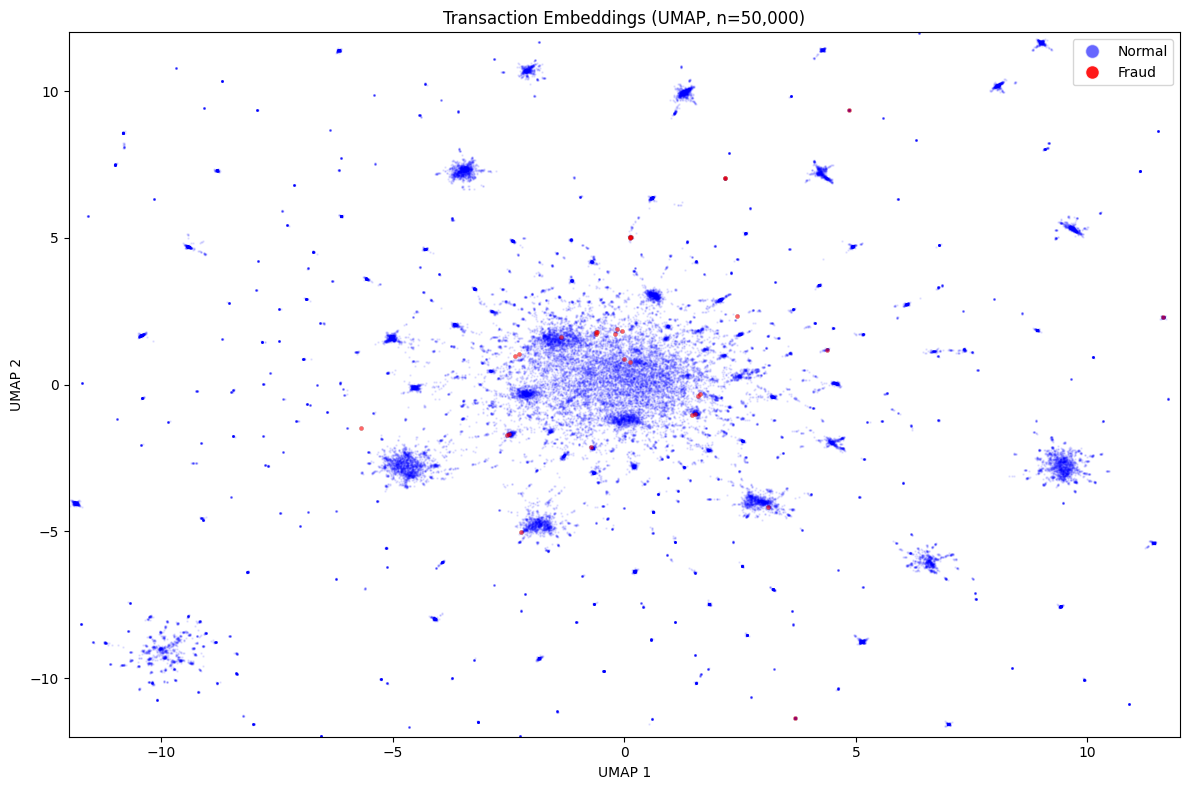

Saved → /workspace/data/embeddings/umap_visualization.png


In [5]:
%pip install -q plotly

import matplotlib
import plotly.graph_objects as go
import matplotlib.cm as _cm
from matplotlib.lines import Line2D
from IPython.display import IFrame, HTML, display as ipy_display

# ── Build viz_df (reused by the 3D interactive plot below) ────────────
viz_df = pd.DataFrame({
    "umap_1": umap_2d[:, 0],
    "umap_2": umap_2d[:, 1],
    "industry": subset_raw["industry"].fillna("Unknown").values,
    "mcc": subset_raw["MCC"].fillna(-1).astype(int).astype(str).values,
    "state": subset_raw["state"].fillna("XX").values,
    "chip_type": subset_raw["chip_type"].fillna("Unknown").values,
    "amount_bucket": subset_raw["amount_bucket"].fillna("Unknown").values,
    "zip3": subset_raw["zip3"].fillna("000").values,
    "fraud": ["Fraud" if l == 1 else "Normal" for l in subset_labels],
    "city": subset_raw["Merchant City"].fillna("Unknown").values,
})

def _tab20_hex(n):
    """Return n hex colors from matplotlib tab20."""
    cmap = matplotlib.colormaps["tab20"].resampled(max(n, 2))
    return [
        "#{:02x}{:02x}{:02x}".format(int(r*255), int(g*255), int(b*255))
        for r, g, b, _ in [cmap(i) for i in range(n)]
    ]

GRAY = "#d3d3d3"

# ── Static 2D scatter: Fraud vs Normal ────────────────────────────────
plt.figure(figsize=(12, 8))

if subset_labels is not None:
    mask_normal = (subset_labels == 0)
    mask_fraud = (subset_labels == 1)

    plt.scatter(
        umap_2d[mask_normal, 0], umap_2d[mask_normal, 1],
        c="blue", alpha=0.08, s=0.7, label="Normal",
    )
    plt.scatter(
        umap_2d[mask_fraud, 0], umap_2d[mask_fraud, 1],
        c="red", alpha=0.6, s=10, label="Fraud",
        edgecolor="k", linewidth=0.1,
    )
    plt.legend(handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor="blue",
               markersize=10, alpha=0.6, label="Normal"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="red",
               markersize=10, alpha=0.9, label="Fraud"),
    ], loc="upper right")
else:
    plt.scatter(umap_2d[:, 0], umap_2d[:, 1], alpha=0.3, s=1)

plt.title(f"Transaction Embeddings (UMAP, n={len(subset_embeds):,})")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.xlim(-AXIS_RANGE, AXIS_RANGE)
plt.ylim(-AXIS_RANGE, AXIS_RANGE)
plt.tight_layout()
plt.savefig(EMBED_DIR / "umap_visualization.png", dpi=150)
plt.show()
print(f"Saved \u2192 {EMBED_DIR / 'umap_visualization.png'}")


### 3D Interactive UMAP with Feature Toggle

GPU-accelerated 3D UMAP with a dropdown to switch color-coding between features.

> **Viewing the plot:** The cell below renders inside an IFrame. If it appears blank, open `data/embeddings/umap_3d_interactive.html` directly in your browser.

In [6]:
print(f"Running GPU-accelerated 3D UMAP on {len(subset_embeds):,} samples...")

umap_3d_model = cumlUMAP(
    n_neighbors=15,
    n_components=3,
    min_dist=0.1,
    metric='euclidean',
    random_state=42,
)
umap_3d = umap_3d_model.fit_transform(embeds_gpu)
umap_3d = cp.asnumpy(umap_3d)
print(f"3D UMAP complete: {umap_3d.shape}")

viz_df["umap3_x"] = umap_3d[:, 0]
viz_df["umap3_y"] = umap_3d[:, 1]
viz_df["umap3_z"] = umap_3d[:, 2]

toggle_3d_specs = [
    ("Fraud",             "fraud",         None),
    ("Industry",          "industry",      None),
    ("Industry (top 8)",  "industry",      8),
    ("State",             "state",         None),
    ("State (top 4)",     "state",         4),
    ("Chip Type",         "chip_type",     None),
    ("Amount Bucket",     "amount_bucket", None),
    ("ZIP3 (top 10)",     "zip3",          10),
]

hover_3d = [
    f"Industry: {row.industry}<br>MCC: {row.mcc}<br>State: {row.state}<br>"
    f"City: {row.city}<br>Chip: {row.chip_type}<br>Amount: {row.amount_bucket}<br>"
    f"Fraud: {row.fraud}"
    for row in viz_df.itertuples()
]

# ── Pre-compute one color array per dropdown option ───────────────────
# Single Scatter3d trace; buttons swap only marker.color.
color_arrays_3d = []
for _label, col, top_n in toggle_3d_specs:
    vals = viz_df[col].values
    if top_n is not None:
        top_vals = viz_df[col].value_counts().head(top_n).index.tolist()
        colors = _tab20_hex(len(top_vals))
        color_map = dict(zip(top_vals, colors))
    else:
        unique_vals = sorted(viz_df[col].dropna().unique())
        colors = _tab20_hex(len(unique_vals))
        color_map = dict(zip(unique_vals, colors))
    color_arrays_3d.append([color_map.get(v, GRAY) for v in vals])

fig3d = go.Figure()
fig3d.add_trace(go.Scatter3d(
    x=viz_df["umap3_x"], y=viz_df["umap3_y"], z=viz_df["umap3_z"],
    mode="markers",
    marker=dict(size=1.5, color=color_arrays_3d[0], opacity=0.5),
    text=hover_3d,
    hoverinfo="text",
    name=toggle_3d_specs[0][0],
))

buttons_3d = []
for i, (label, col, top_n) in enumerate(toggle_3d_specs):
    buttons_3d.append(dict(
        label=label,
        method="update",
        args=[
            {"marker.color": [color_arrays_3d[i]], "name": [label]},
            {"title.text": f"3D Embedding Explorer \u2014 {label}"},
        ],
    ))

fig3d.update_layout(
    title=dict(
        text=f"3D Embedding Explorer \u2014 Fraud (n={len(viz_df):,})",
        x=0.5, xanchor="center", y=0.97, yanchor="top",
    ),
    scene=dict(
        xaxis=dict(title="UMAP 1", range=[-AXIS_RANGE, AXIS_RANGE]),
        yaxis=dict(title="UMAP 2", range=[-AXIS_RANGE, AXIS_RANGE]),
        zaxis=dict(title="UMAP 3", range=[-AXIS_RANGE, AXIS_RANGE]),
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.2)),
    ),
    updatemenus=[dict(
        type="dropdown", direction="down",
        x=0.01, xanchor="left", y=0.97, yanchor="top",
        buttons=buttons_3d,
        bgcolor="white", bordercolor="gray",
    )],
    width=950, height=750,
    margin=dict(l=0, r=0, b=0, t=80),
    showlegend=False,
)

html_path_3d = EMBED_DIR / "umap_3d_interactive.html"
fig3d.write_html(str(html_path_3d), include_plotlyjs=True)
print(f"Saved \u2192 {html_path_3d}")

# Display inline via IFrame — keeps the notebook output tiny.
# If the IFrame appears blank, open the saved HTML file directly in your browser.
try:
    rel_path_3d = str(html_path_3d.relative_to(Path(".").resolve()))
    ipy_display(IFrame(src=rel_path_3d, width="100%", height="780px"))
except Exception:
    ipy_display(HTML(
        f"<b>Interactive 3D plot saved.</b> "
        f'Open in your browser: <a href="{html_path_3d}" target="_blank">{html_path_3d.name}</a>'
    ))


Running GPU-accelerated 3D UMAP on 50,000 samples...


3D UMAP complete: (50000, 3)


Saved → /workspace/data/embeddings/umap_3d_interactive.html


In [7]:
print("=" * 60)
print("Embedding Extraction Complete!")
print("=" * 60)
print(f"\nOutputs saved to: {EMBED_DIR}")
print(f"  - train_embeddings.npy  (balanced ~1M sample)")
print(f"  - train_labels.npy")
print(f"  - train_row_ids.npy")
print(f"  - val_embeddings.npy:  {val_emb.shape}")
print(f"  - val_labels.npy:      {val_lbl.shape}")
print(f"  - val_row_ids.npy")
print(f"  - test_embeddings.npy: {test_emb.shape}")
print(f"  - test_labels.npy:     {test_lbl.shape}")
print(f"  - test_row_ids.npy")
print(f"  - metadata.json")
print(f"\nVisualizations:")
print(f"  - umap_visualization.png            (static 2D Fraud vs Normal)")
print(f"  - umap_3d_interactive.html          (Plotly 3D with feature toggle)")
print(f"\nNext: Use embeddings in Notebook 05 for fraud detection!")


Embedding Extraction Complete!

Outputs saved to: /workspace/data/embeddings
  - train_embeddings.npy  (balanced ~1M sample)
  - train_labels.npy
  - train_row_ids.npy
  - val_embeddings.npy:  (100000, 512)
  - val_labels.npy:      (100000,)
  - val_row_ids.npy
  - test_embeddings.npy: (100000, 512)
  - test_labels.npy:     (100000,)
  - test_row_ids.npy
  - metadata.json

Visualizations:
  - umap_visualization.png            (static 2D Fraud vs Normal)
  - umap_3d_interactive.html          (Plotly 3D with feature toggle)

Next: Use embeddings in Notebook 05 for fraud detection!


## Summary

Extracted 512d last-token embeddings for a balanced 1M training sample and 100k stratified val/test subsets, then visualized the embedding space with GPU-accelerated UMAP.

**Visualizations:**
| Plot | File | In-notebook display |
|------|------|---------------------|
| 2D UMAP — Fraud vs Normal | `umap_visualization.png` | Static matplotlib |
| 3D UMAP with feature-toggle dropdown | `umap_3d_interactive.html` | IFrame (Jupyter file server) |

> **If the 3D plot cell shows a blank frame:** Open `data/embeddings/umap_3d_interactive.html` directly in any browser as a fallback — the file is fully self-contained (plotly.js bundled, no internet required).

**Outputs:** `train_embeddings.npy`, `val_embeddings.npy`, `test_embeddings.npy`, `train_labels.npy`, `val_labels.npy`, `test_labels.npy`, `train_row_ids.npy`, `val_row_ids.npy`, `test_row_ids.npy`, `metadata.json`

Continue to [05_xgboost_fraud_detection.ipynb](./05_xgboost_fraud_detection.ipynb).
